# Predicting the growth performance (rmax) and thermal optimum (topt) of a fungal pathogen across temperatures

## Using Thermal Performance Curve Modelling from the rTPC package

In [ ]:
R.version 4.4.3

## R packages

In [1]:
library(ggplot2)
library(ggpubr)
library(tidyr)
library(tidyverse)
library(broom)
library(MuMIn)
library(nls.multstart)
library(purrr)
library(rTPC)

ERROR: there is no package called ‘ggpubr’

# Step 1 - Loading datasets

In [8]:
# Load dataset 
Radial_growth_ex

ERROR: object 'Radial_growth_ex' not found

# Step 2 - Data cleaning & preparation

In [5]:
Radial_growth_ex <- Radial_growth_ex %>%
  filter(!Day %in% c(0))

Radial_growth_ex <- Radial_growth_ex %>%
  filter(!Adj_Radial_growth_rate_cm.day %in% c(NA))

ERROR: could not find function "%>%"

# Step 3 - Subset data and run through 10 selected TPC models

In [ ]:
# Subset dataframe to include Day 4 
d<-Radial_growth_ex[Radial_growth_ex$Day=="4",]

# Step 4 - Fit growth data to 10 selected Thermal Performance Models using rTPC package

In [ ]:
# Fit growth data to TPC models
d_fits <- nest(d, data = c(temperature, Adj_Radial_growth_rate_cm.day)) %>%
  mutate(briere2 = map(data, ~nls_multstart(Adj_Radial_growth_rate_cm.day~briere2_1999(temp = temperature, tmin, tmax, a,b),
                                            data = d,
                                            iter = c(4,4,4,4),
                                            start_lower = get_start_vals(d$temperature, d$Adj_Radial_growth_rate_cm.day, model_name = 'briere2_1999') - 5,
                                            start_upper = get_start_vals(d$temperature, d$Adj_Radial_growth_rate_cm.day, model_name = 'briere2_1999') + 5,
                                            lower = get_lower_lims(d$temperature, d$Adj_Radial_growth_rate_cm.day, model_name = 'briere2_1999'),
                                            upper = get_upper_lims(d$temperature, d$Adj_Radial_growth_rate_cm.day, model_name = 'briere2_1999'),
                                            supp_errors = 'Y',
                                            convergence_count = FALSE)),
         gaussian = map(data, ~nls_multstart(Adj_Radial_growth_rate_cm.day~gaussian_1987(temp = temperature, rmax, topt, a),
                                             data = d,
                                             iter = c(4,4,4),
                                             start_lower = get_start_vals(d$temperature, d$Adj_Radial_growth_rate_cm.day, model_name = 'gaussian_1987') - 10,
                                             start_upper = get_start_vals(d$temperature, d$Adj_Radial_growth_rate_cm.day, model_name = 'gaussian_1987') + 10,
                                             lower = get_lower_lims(d$temperature, d$Adj_Radial_growth_rate_cm.day, model_name = 'gaussian_1987'),
                                             upper = get_upper_lims(d$temperature, d$Adj_Radial_growth_rate_cm.day, model_name = 'gaussian_1987'),
                                             supp_errors = 'Y',
                                             convergence_count = FALSE)),
         modifiedgaussian = map(data, ~nls_multstart(Adj_Radial_growth_rate_cm.day~modifiedgaussian_2006(temp = temperature, rmax, topt, a, b),
                                                     data = d,
                                                     iter = c(4,4,4,4),
                                                     start_lower = get_start_vals(d$temperature, d$Adj_Radial_growth_rate_cm.day, model_name = 'modifiedgaussian_2006') - 5,
                                                     start_upper = get_start_vals(d$temperature, d$Adj_Radial_growth_rate_cm.day, model_name = 'modifiedgaussian_2006') + 5,
                                                     lower = get_lower_lims(d$temperature, d$Adj_Radial_growth_rate_cm.day, model_name = 'modifiedgaussian_2006'),
                                                     upper = get_upper_lims(d$temperature, d$Adj_Radial_growth_rate_cm.day, model_name = 'modifiedgaussian_2006'),
                                                     supp_errors = 'Y',
                                                     convergence_count = FALSE)),
         lactin2 = map(data, ~nls_multstart(Adj_Radial_growth_rate_cm.day~lactin2_1995(temp = temperature, a, b, tmax, delta_t),
                                            data = d,
                                            iter = c(4,4,4,4),
                                            start_lower = get_start_vals(d$temperature, d$Adj_Radial_growth_rate_cm.day, model_name = 'lactin2_1995') - 10,
                                            start_upper = get_start_vals(d$temperature, d$Adj_Radial_growth_rate_cm.day, model_name = 'lactin2_1995') + 10,
                                            lower = get_lower_lims(d$temperature, d$Adj_Radial_growth_rate_cm.day, model_name = 'lactin2_1995'),
                                            upper = get_upper_lims(d$temperature, d$Adj_Radial_growth_rate_cm.day, model_name = 'lactin2_1995'),
                                            supp_errors = 'Y',
                                            convergence_count = FALSE)),
          ratkowsky = map(data, ~nls_multstart(Adj_Radial_growth_rate_cm.day~ratkowsky_1983(temp = temperature, tmin, tmax, a, b),
                                              data = d,
                                              iter = c(4,4,4,4),
                                              start_lower = get_start_vals(d$temperature, d$Adj_Radial_growth_rate_cm.day, model_name = 'ratkowsky_1983') - 5,
                                              start_upper = get_start_vals(d$temperature, d$Adj_Radial_growth_rate_cm.day, model_name = 'ratkowsky_1983') + 5,
                                              lower = get_lower_lims(d$temperature, d$Adj_Radial_growth_rate_cm.day, model_name = 'ratkowsky_1983'),
                                              upper = get_upper_lims(d$temperature, d$Adj_Radial_growth_rate_cm.day, model_name = 'ratkowsky_1983'),
                                              supp_errors = 'Y',
                                              convergence_count = FALSE)),
         sharpeschoolhigh = map(data, ~nls_multstart(Adj_Radial_growth_rate_cm.day~sharpeschoolhigh_1981(temp = temperature, r_tref,e,eh,th, tref = 25),
                                                     data = d,
                                                     iter = c(4,4,4,4),
                                                     start_lower = get_start_vals(d$temperature, d$Adj_Radial_growth_rate_cm.day, model_name = 'sharpeschoolhigh_1981') - 10,
                                                     start_upper = get_start_vals(d$temperature, d$Adj_Radial_growth_rate_cm.day, model_name = 'sharpeschoolhigh_1981') + 10,
                                                     lower = get_lower_lims(d$temperature, d$Adj_Radial_growth_rate_cm.day, model_name = 'sharpeschoolhigh_1981'),
                                                     upper = get_upper_lims(d$temperature, d$Adj_Radial_growth_rate_cm.day, model_name = 'sharpeschoolhigh_1981'),
                                                     supp_errors = 'Y',
                                                     convergence_count = FALSE)),
         quadratic = map(data, ~nls_multstart(Adj_Radial_growth_rate_cm.day~quadratic_2008(temp = temperature, a, b, c),
                                              data = d,
                                              iter = c(4,4,4),
                                              start_lower = get_start_vals(d$temperature, d$Adj_Radial_growth_rate_cm.day, model_name = 'quadratic_2008') - 5,
                                              start_upper = get_start_vals(d$temperature, d$Adj_Radial_growth_rate_cm.day, model_name = 'quadratic_2008') + 5,
                                              lower = get_lower_lims(d$temperature, d$Adj_Radial_growth_rate_cm.day, model_name = 'quadratic_2008'),
                                              upper = get_upper_lims(d$temperature, d$Adj_Radial_growth_rate_cm.day, model_name = 'quadratic_2008'),
                                              supp_errors = 'Y',
                                              convergence_count = FALSE)),
         oneill = map(data, ~nls_multstart(Adj_Radial_growth_rate_cm.day~oneill_1972(temp = temperature, rmax, ctmax, topt, q10),
                                           data = d,
                                           iter = c(4,4,4,4),
                                           start_lower = get_start_vals(d$temperature, d$Adj_Radial_growth_rate_cm.day, model_name = 'oneill_1972') - 10,
                                           start_upper = get_start_vals(d$temperature, d$Adj_Radial_growth_rate_cm.day, model_name = 'oneill_1972') + 10,
                                           lower = get_lower_lims(d$temperature, d$Adj_Radial_growth_rate_cm.day, model_name = 'oneill_1972'),
                                           upper = get_upper_lims(d$temperature, d$Adj_Radial_growth_rate_cm.day, model_name = 'oneill_1972'),
                                           supp_errors = 'Y',
                                           convergence_count = FALSE)),
         pawar = map(data, ~nls_multstart(Adj_Radial_growth_rate_cm.day~pawar_2018(temp = temperature, r_tref, e, eh, topt, tref = 25),
                                          data = d,
                                          iter = c(4,4,4,4),
                                          start_lower = get_start_vals(d$temperature, d$Adj_Radial_growth_rate_cm.day, model_name = 'pawar_2018') - 10,
                                          start_upper = get_start_vals(d$temperature, d$Adj_Radial_growth_rate_cm.day, model_name = 'pawar_2018') + 10,
                                          lower = get_lower_lims(d$temperature, d$Adj_Radial_growth_rate_cm.day, model_name = 'pawar_2018'),
                                          upper = get_upper_lims(d$temperature, d$Adj_Radial_growth_rate_cm.day, model_name = 'pawar_2018'),
                                          supp_errors = 'Y',
                                          convergence_count = FALSE)),
         weibull = map(data, ~nls_multstart(Adj_Radial_growth_rate_cm.day~weibull_1995(temp = temperature, a,topt,b,c),
                                            data = d,
                                            iter = c(4,4,4,4),
                                            start_lower = get_start_vals(d$temperature, d$Adj_Radial_growth_rate_cm.day, model_name = 'weibull_1995') - 10,
                                            start_upper = get_start_vals(d$temperature, d$Adj_Radial_growth_rate_cm.day, model_name = 'weibull_1995') + 10,
                                            lower = get_lower_lims(d$temperature, d$Adj_Radial_growth_rate_cm.day, model_name = 'weibull_1995'),
                                            upper = get_upper_lims(d$temperature, d$Adj_Radial_growth_rate_cm.day, model_name = 'weibull_1995'),
                                            supp_errors = 'Y')))

names(d_fits)
glimpse(select(d_fits, 1:7))
d_fits$briere2[[1]]

# stack models
d_stack <- select(d_fits, -data) %>%
  pivot_longer(., names_to = 'model_name', values_to = 'fit', briere2:weibull)

# get predictions using augment
newdata <- tibble(temperature = seq(min(d$temperature), max(d$temperature), length.out = 100))
d_preds <- d_stack %>%
  mutate(d_stack, preds = map(fit, augment, newdata = newdata)) %>%
  select(-fit) %>%
  unnest(preds)

d_preds$model_name


# Step 5 - Inspect data

In [ ]:
names(d_fits)
glimpse(select(d_fits, 1:7))

In [ ]:
Rows: 21
Columns: 7
$ `Time(days)`  <dbl> 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4
$ Day           <dbl> 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4
$ ID            <chr> "C1", "C2", "C3", "C1", "C2", "C3", "C1", "C2", "C3", "C1", "C2", "C3", "C1", "C2", "C3", "C1", "C2", "C3", "C1", "C2", "C3"
$ Replicate     <dbl> 1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2, 3
$ Diameter_1_cm <dbl> 3.603700, 3.568000, 3.500000, 3.802400, 3.660000, 3.964000, 4.170000, 4.180000, 4.708000, 4.880000, 5.316684, 5.136000, 5.74600…
$ Diameter_2_cm <dbl> 3.426000, 3.770000, 3.610000, 3.851000, 3.750000, 3.684000, 4.270000, 4.116000, 4.416000, 4.942000, 5.355000, 5.444000, 6.34400…
$ Average       <dbl> 3.514850, 3.669000, 3.555000, 3.826700, 3.705000, 3.824000, 4.220000, 4.148000, 4.562000, 4.911000, 5.335842, 5.290000, 6.04500…

# Step 6 - Stack models and get predictions

In [ ]:
# stack models
d_stack <- select(d_fits, -data) %>%
  pivot_longer(., names_to = 'model_name', values_to = 'fit', briere2:weibull)

# get predictions using augment
newdata <- tibble(temperature = seq(min(d$temperature), max(d$temperature), length.out = 100))
d_preds <- d_stack %>%
  mutate(d_stack, preds = map(fit, augment, newdata = newdata)) %>%
  select(-fit) %>%
  unnest(preds)

# Step 7 - Plot all 10 selected models

In [ ]:
# plot
g4<-ggplot(d_preds, aes(temperature, Adj_Radial_growth_rate_cm.day)) +
  geom_point(aes(temperature, Adj_Radial_growth_rate_cm.day), d) +
  geom_line(aes(temperature, .fitted), col = "blue") +
  facet_wrap(~model_name, labeller = labeller(model_name= label_both), scales = 'free', ncol = 5) +
  theme_bw(base_size = 13) +
  theme(legend.position = 'none',
        strip.text = element_text(hjust = 0),
        strip.background = element_blank()) +
  labs(x = 'Temperature (ºC)',
       y = 'Growth rate (cm²/day)',
       geom_hline(aes(yintercept = 0), linetype = 2),
       coord_cartesian(ylim = c(0, 0.2)))

plot(g4)
ggsave("g4.png", width = 15, height = 7)

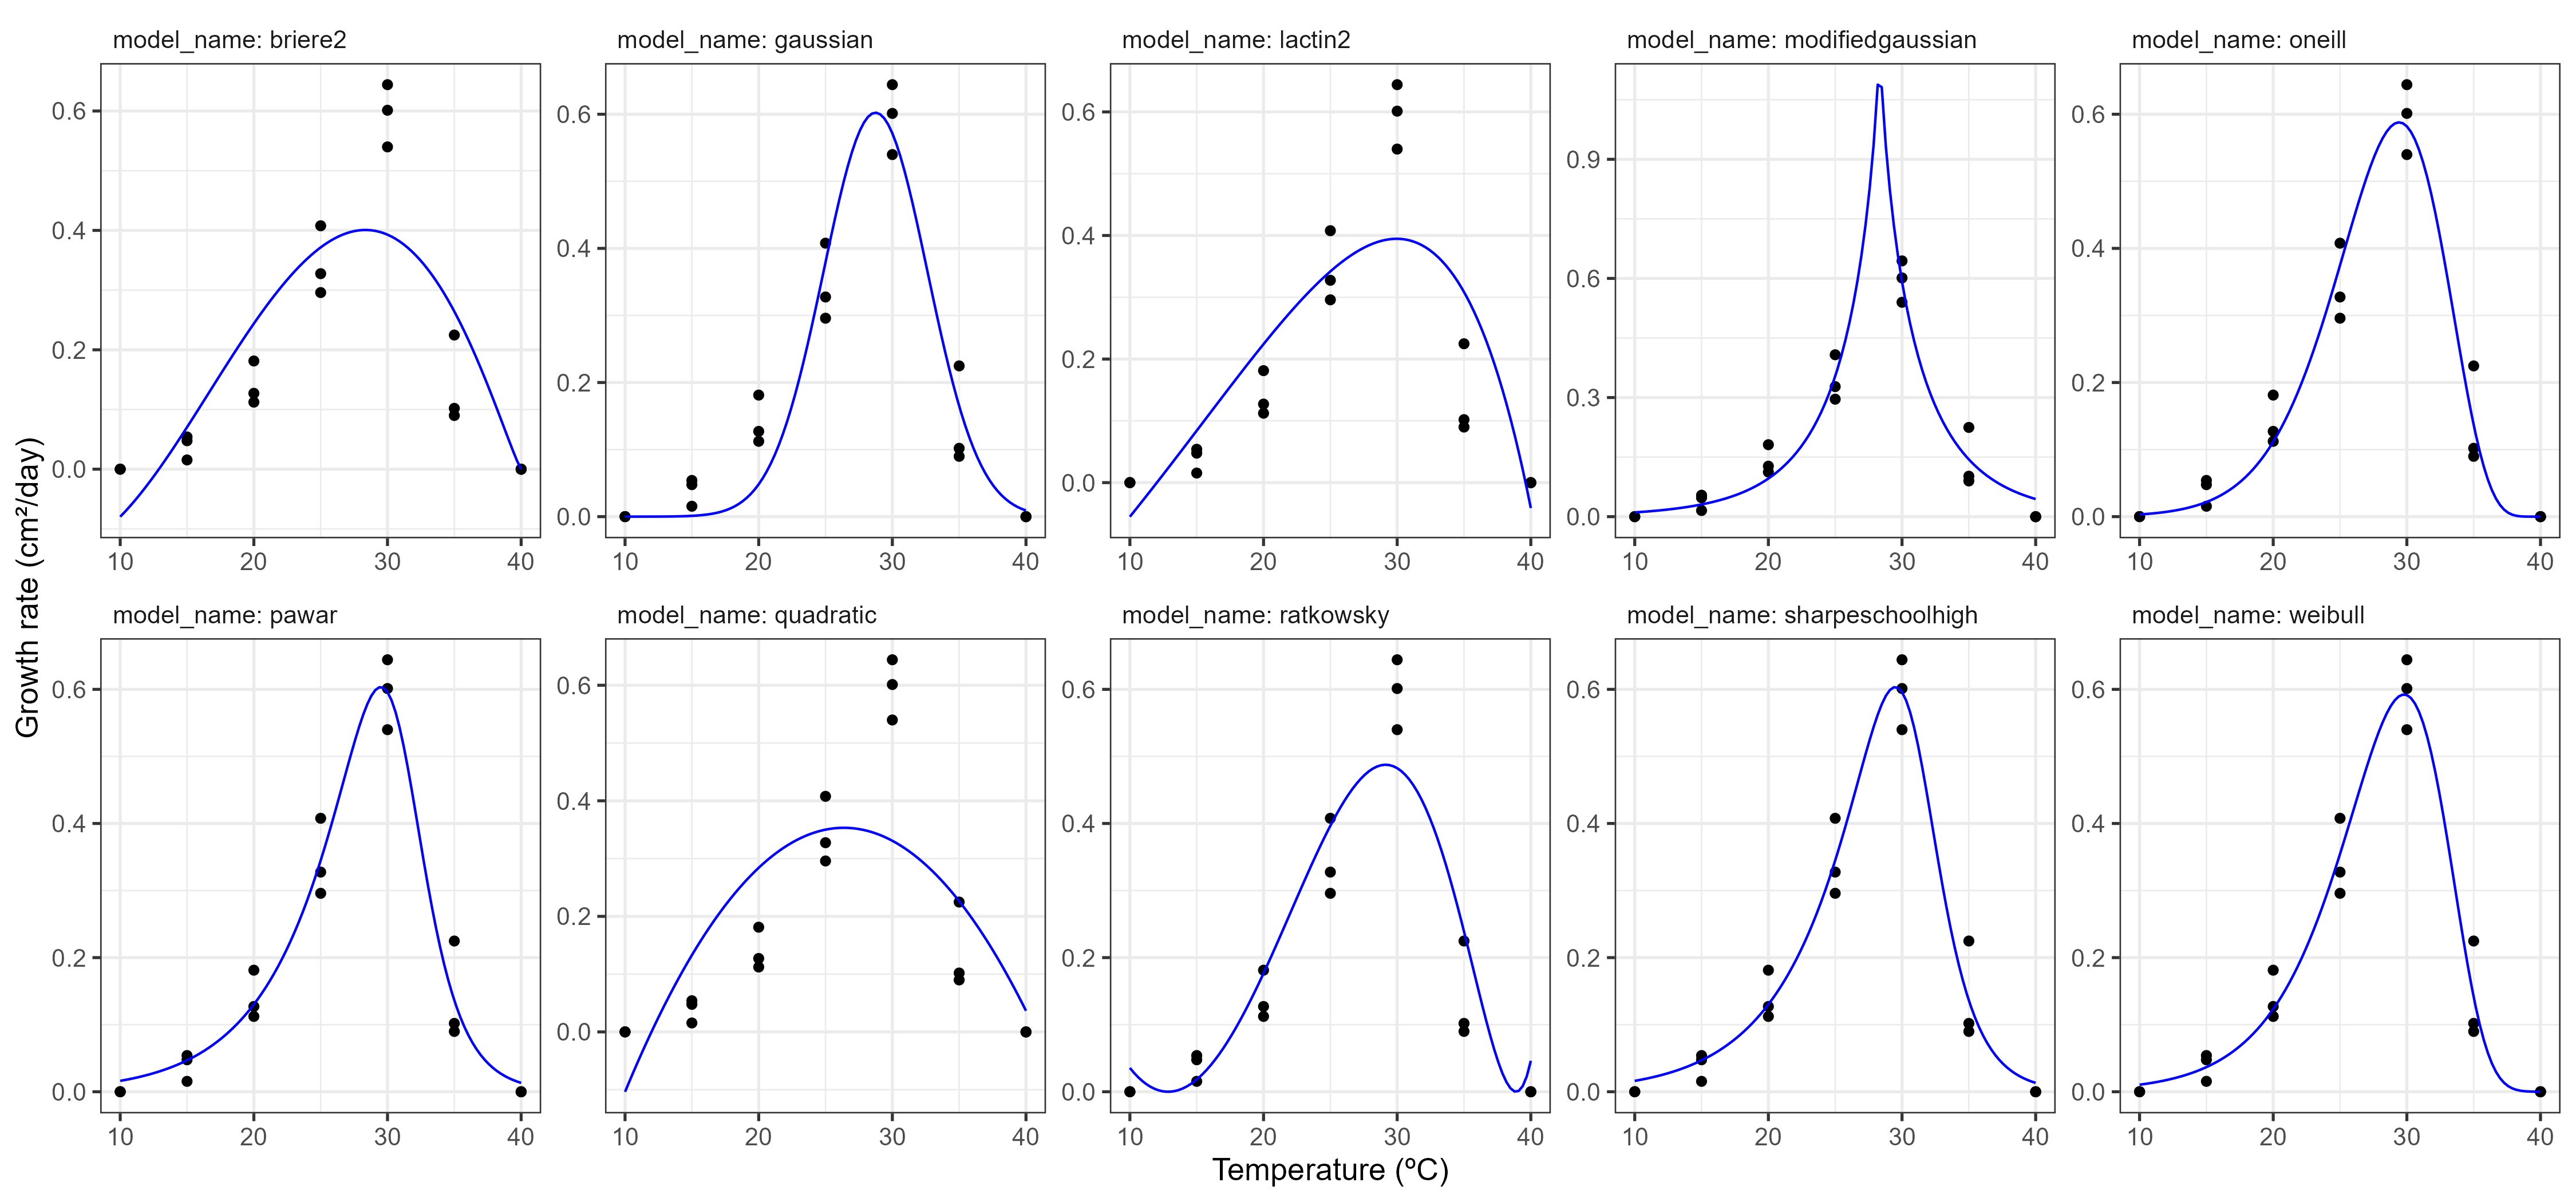

# Step 8 - Calculate AIC scores and compare

In [ ]:
AIC_values <- sapply(d_fits, function(model) {
  if (inherits(model, "list") && length(model) > 0) {  
    model <- model[[1]]  # Extract the first sublist (which is the actual `nls` object)}
  if (inherits(model, "nls")) {AIC(model)} else {NA }})
view(AIC_values)
d_compare <- d_stack %>%
  mutate(
    AIC = map_dbl(fit, ~ if (inherits(.x, "nls")) AIC(.x) else NA_real_),
    BIC = map_dbl(fit, ~ if (inherits(.x, "nls")) BIC(.x) else NA_real_)
  ) %>%
  select(ID, model_name, AIC, BIC)
d_compare

In [ ]:
A tibble: 210 × 4
   ID    model_name         AIC   BIC
   <chr> <chr>            <dbl> <dbl>
 1 C1    briere2          -23.2 -18.0
 2 C1    gaussian         -54.0 -49.8
 3 C1    modifiedgaussian -62.2 -57.0
 4 C1    lactin2          -21.4 -16.2
 5 C1    ratkowsky        -39.1 -33.9
 6 C1    sharpeschoolhigh -69.0 -63.8
 7 C1    quadratic        -16.4 -12.3
 8 C1    oneill           -65.6 -60.4
 9 C1    pawar            -69.0 -63.8
10 C1    weibull          -69.1 -63.9
# ℹ 200 more rows
# ℹ Use `print(n = ...)` to see more rows   

# Step 9 - Lowest AIC score = best fit model

In [ ]:
best_model <- names(which.min(AIC_values))
print(best_model)

[1] "weibull"

# Step 10 - Plot Best model (Weibull) and find the Thermal Optimum (Top) and growth performance (Rmax)

In [ ]:
mod = 'weibull_1995'
#get start values
start_vals <- get_start_vals(d$temperature, d$Adj_Radial_growth_rate_cm.day, model_name = 'weibull_1995')
# get limits
low_lims <- get_lower_lims(d$temperature, d$Adj_Radial_growth_rate_cm.day, model_name = 'weibull_1995')
upper_lims <- get_upper_lims(d$temperature, d$Adj_Radial_growth_rate_cm.day, model_name = 'weibull_1995')

start_vals
low_lims

fit <- nls.multstart::nls_multstart(Adj_Radial_growth_rate_cm.day~weibull_1995(temp = temperature, a,topt,b,c),
                                    data = d,
                                    iter = c(4,4,4,4),
                                    start_lower = start_vals - 5,
                                    start_upper = start_vals + 5,
                                    lower = low_lims,
                                    upper = upper_lims,
                                    supp_errors = 'Y') 
fit

In [ ]:
Nonlinear regression model
  model: Adj_Radial_growth_rate_cm.day ~ weibull_1995(temp = temperature,     a, topt, b, c)
   data: data
        a      topt         b         c 
5.923e-01 2.979e+01 3.404e+05 8.648e+04 
 residual sum-of-squares: 0.02839

Number of iterations to convergence: 43 
Achieved convergence tolerance: 1.49e-08

# Step 11 Calculate parameters - Rmax (performance rate) and Topt (thermal optimum)

In [ ]:
calc_params(fit) %>%
  # round for easy viewing
  mutate_all(round, 2)

In [ ]:
Rmax  Topt Ctmin Ctmax    e  eh  q10 thermal_safety_margin thermal_tolerance breadth skewness
0.59 29.79 14.13 55.83 1.49 2.5 7.39                 26.04              41.7    5.34    -1.01

# Step 12 Predict new data and plot

In [ ]:
# predict new data
new_data <- data.frame(temperature = seq(min(d$temperature), max(d$temperature), length.out = 100))
d_preds<-augment(fit, newdata = new_data)

# plot data and model fit
plotwei<-ggplot(d, aes(temperature, Adj_Radial_growth_rate_cm.day)) +
  geom_point(aes(temperature, Adj_Radial_growth_rate_cm.day),d) +
  geom_line(aes(temperature, .fitted), linewidth = 1, d_preds, col = 'blue') +
  coord_cartesian(ylim = c(0, 0.75))+
  theme_bw(base_size = 14) +
  labs(x = 'Temperature (ºC)',
       y = 'Growth rate (cm/day)')+
  theme(plot.background = element_rect(fill = "white", color = NA),
        strip.background = element_rect(fill = "white", color = "grey", linewidth = 0.6),
        panel.border = element_rect(color = "grey", fill = NA, linewidth = 0.6),
        strip.text = element_text(size = 13),
        axis.title = element_text(size = 15), # makes axis titles bigger
        axis.text = element_text(size = 13), # makes tick labels bigger
        axis.title.x = element_text(margin = margin(t = 13)),  # Increase top margin of x-axis title
        axis.title.y = element_text(margin = margin(r = 13)),   # Increase right margin of y-axis title
        axis.ticks = element_line(colour = "grey"),
        panel.spacing.x = unit(1, "lines"),
        panel.grid.major = element_line(color = "grey90", linewidth = 0.3),
        panel.grid.minor = element_line(color = "grey90", linewidth =0.2),
        legend.title = element_blank())

plot(plotwei)

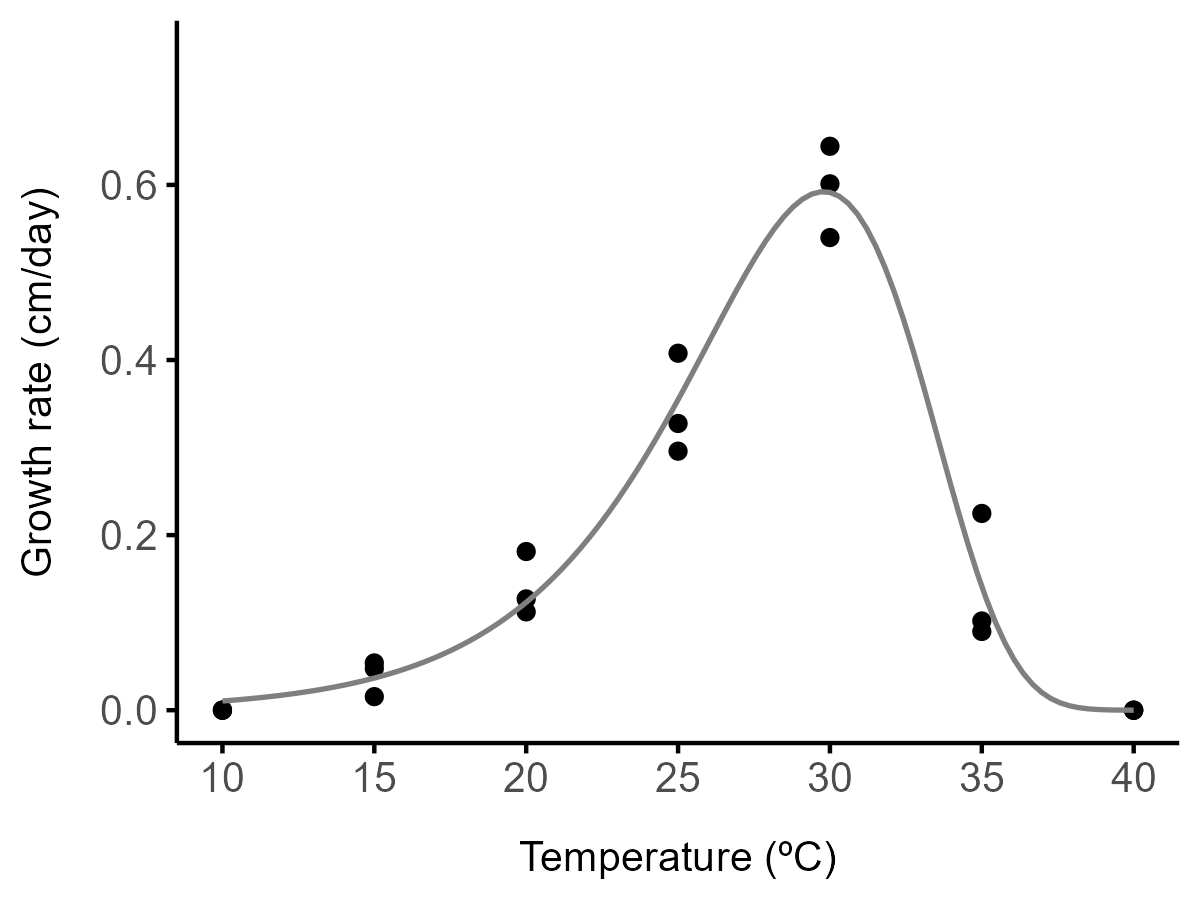

# Step 13 Refit Weibull model using nlsLM

In [ ]:
# refit model using nlsLM
fit_nlsLM <- minpack.lm::nlsLM(Adj_Radial_growth_rate_cm.day~weibull_1995(temp = temperature, a,topt,b,c),
                               data = d,
                               start = as.list(coef(fit)),
                               lower = get_lower_lims(d$temperature, d$Adj_Radial_growth_rate_cm.day, model_name = 'weibull_1995'),
                               upper = get_upper_lims(d$temperature, d$Adj_Radial_growth_rate_cm.day, model_name = 'weibull_1995'),
                               weights = rep(1, times = nrow(d)))


Nonlinear regression model
  model: Adj_Radial_growth_rate_cm.day ~ weibull_1995(temp = temperature,     a, topt, b, c)
   data: d
        a      topt         b         c 
5.923e-01 2.979e+01 3.404e+05 8.648e+04 
 residual sum-of-squares: 0.02839

Number of iterations to convergence: 1 
Achieved convergence tolerance: 1.49e-08

# Step 14 Bootstrap using Case resampling to find Confidence Intervals (CI)

In [ ]:
# bootstrap using case resampling
boot1 <- Boot(fit_nlsLM, method = 'case')

# create predictions of each bootstrapped model
boot1_preds <- boot1$t %>%
  as.data.frame() %>%
  drop_na() %>%
  mutate(iter = 1:n()) %>%
  group_by_all() %>%
  do(data.frame(temperature = seq(min(d$temperature), max(d$temperature), length.out = 100))) %>%
  ungroup() %>%
  mutate(pred = weibull_1995(temp = temperature, a,topt,b,c))

# calculate bootstrapped confidence intervals
boot1_conf_preds <- group_by(boot1_preds, temperature) %>%
  summarise(conf_lower = quantile(pred, 0.025),
            conf_upper = quantile(pred, 0.975)) %>%
  ungroup()

# plot bootstrapped CIs
p1 <- ggplot() +
  geom_line(aes(temperature, .fitted), d_preds, col = 'blue') +
  coord_cartesian(ylim = c(0, 0.8))+
  geom_ribbon(aes(temperature, ymin = conf_lower, ymax = conf_upper), boot1_conf_preds, fill = 'blue', alpha = 0.3) +
  geom_point(aes(temperature, Adj_Radial_growth_rate_cm.day), d, size = 2, alpha = 0.5) +
  theme_bw(base_size = 13) +
  scale_x_continuous(minor_breaks= c(15,25,35), breaks=c(10,15,20,25,30,35,40), labels = c("10", "15", "20", "25", "30", "35", "40"))+ 
  labs(x = 'Temperature (ºC)',
       y = 'Radial growth rate (cm/day)',
       title = 'Bootstrapped confidence intervals: Radial growth rate \n across temperatures')
p1

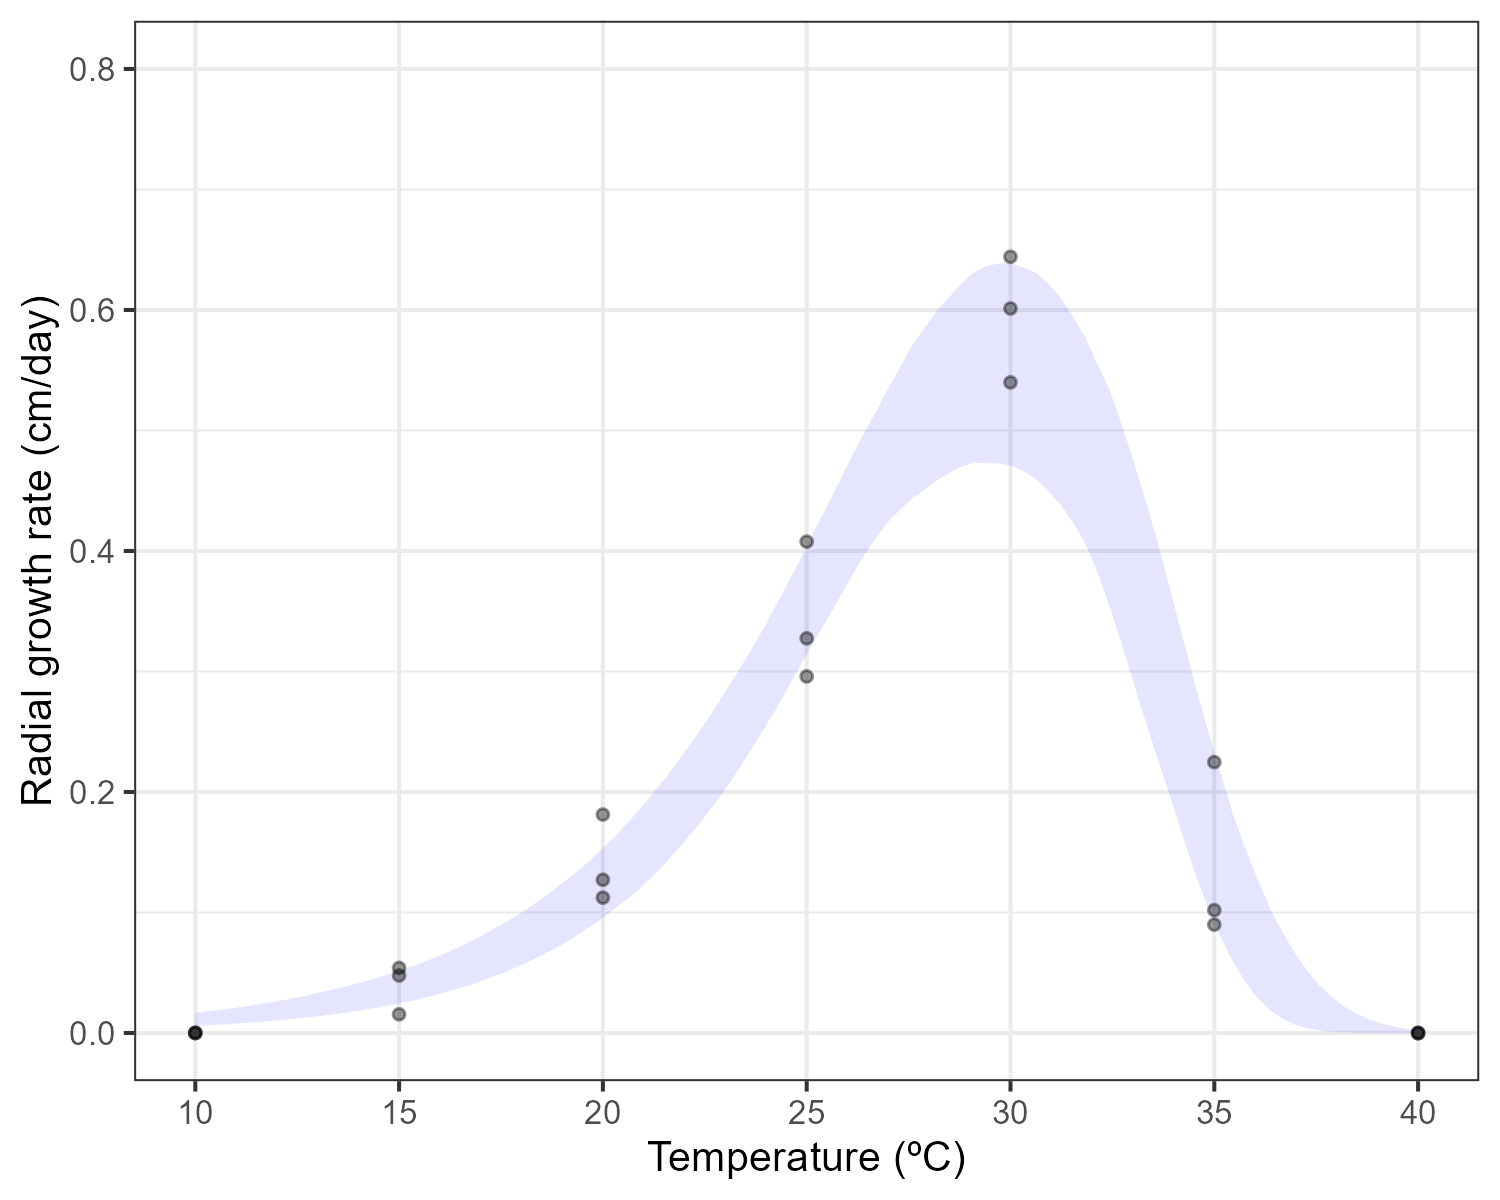

# Step 15 Bootstrap using Case resampling to find Predictions

In [ ]:

# plot bootstrapped predictions
p2 <- ggplot() +
  geom_line(aes(temperature, .fitted), d_preds, col = 'blue') +
  geom_line(aes(temperature, pred, group = iter), boot1_preds, col = 'blue', alpha = 0.007) +
  coord_cartesian(ylim = c(0, 0.8))+
  geom_point(aes(temperature, Adj_Radial_growth_rate_cm.day), d, size = 2, alpha = 0.5) +
  theme_bw(base_size = 13) +
  scale_x_continuous(minor_breaks= c(15,25,35), breaks=c(10,15,20,25,30,35,40), labels = c("10", "15", "20", "25", "30", "35", "40"))+ 
  labs(x = 'Temperature (ºC)',
       y = 'Radial growth rate (cm/day)',
       title = 'Bootstrapped predictions: Radial growth rate \n across temperatures')

p2
ggsave("p2.png", width = 5, height = 4)


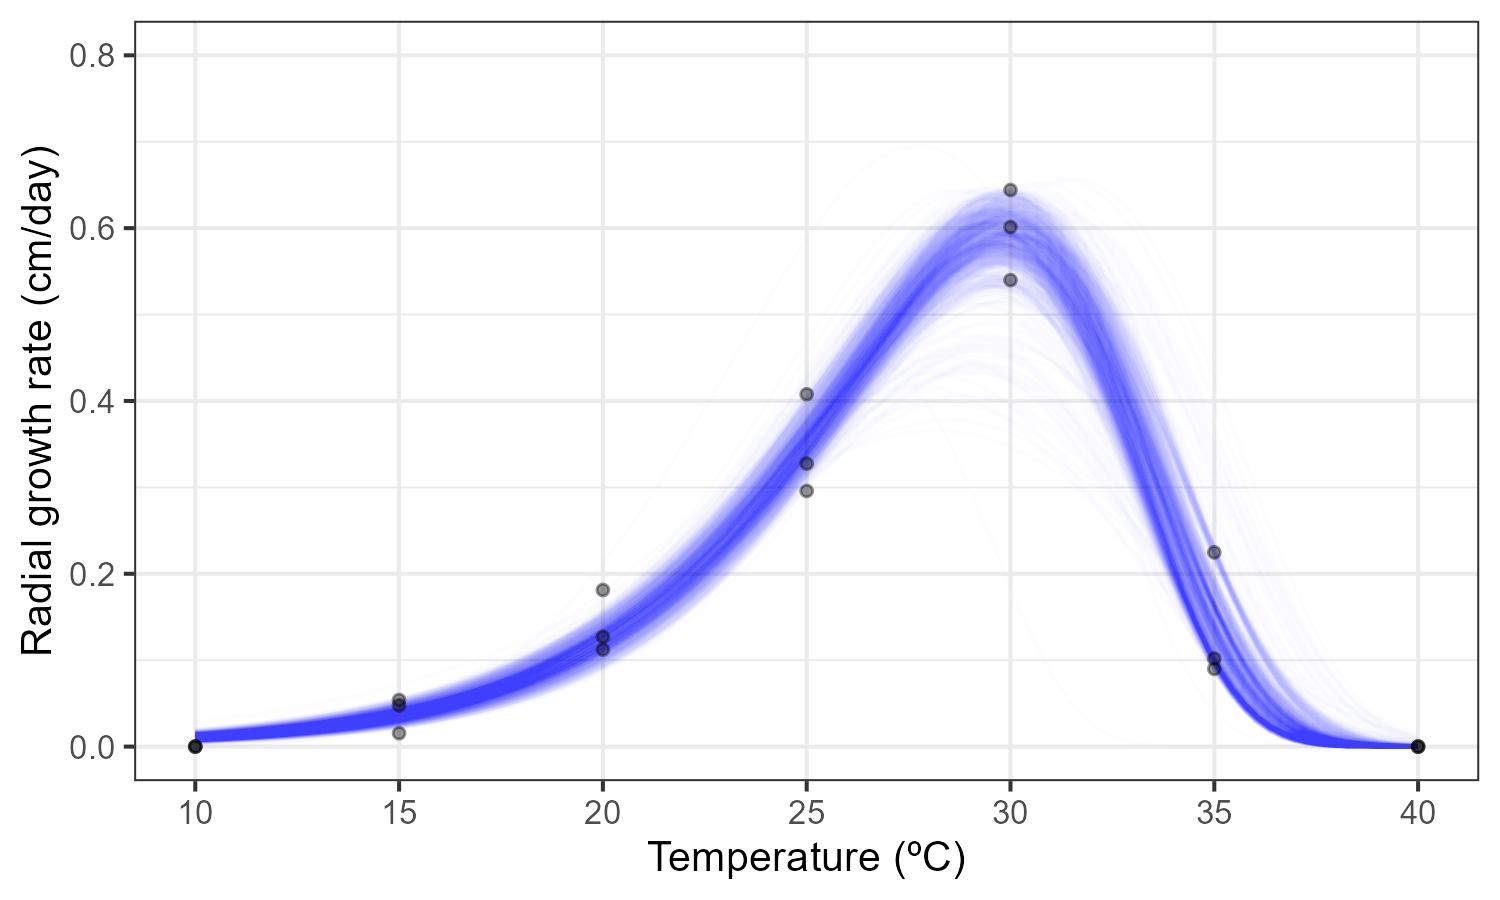

# Step 16 Bootstrap Confidence Intervals for extra parameters

In [ ]:
# bootstrap confidence intervals for the extra parameters
extra_params <- calc_params(fit_nlsLM) %>%
  pivot_longer(everything(), names_to =  'param', values_to = 'estimate') #extracts the model’s parameter estimates (e.g., r_tref, e, eh, th) from your nlsLM fit.

ci_extra_params <- Boot(fit_nlsLM, f = function(x){unlist(calc_params(x))}, labels = names(calc_params(fit_nlsLM)), R = 1000, method = 'case') %>%
  confint(., method = 'bca') %>%
  as.data.frame() %>%
  rename(conf_lower = 1, conf_upper = 2) %>%
  rownames_to_column(., var = 'param') %>%
  mutate(method = 'case bootstrap')

ci_extra_params <- left_join(ci_extra_params, extra_params)
#> Joining, by = "param"

ci_plot<-ggplot(ci_extra_params, aes(param, estimate)) +
  geom_point(size = 4) +
  geom_linerange(aes(ymin = conf_lower, ymax = conf_upper)) +
  theme_bw() +
  facet_wrap(~param, scales = 'free') +
  scale_x_discrete('') +
  labs(title = 'Calculation of confidence intervals for extra parameters',
       subtitle = 'Fusarium TPC; using case resampling')

ci_extra_params
write.csv(ci_extra_params, "CI_day4.csv", row.names = FALSE)
ci_plot

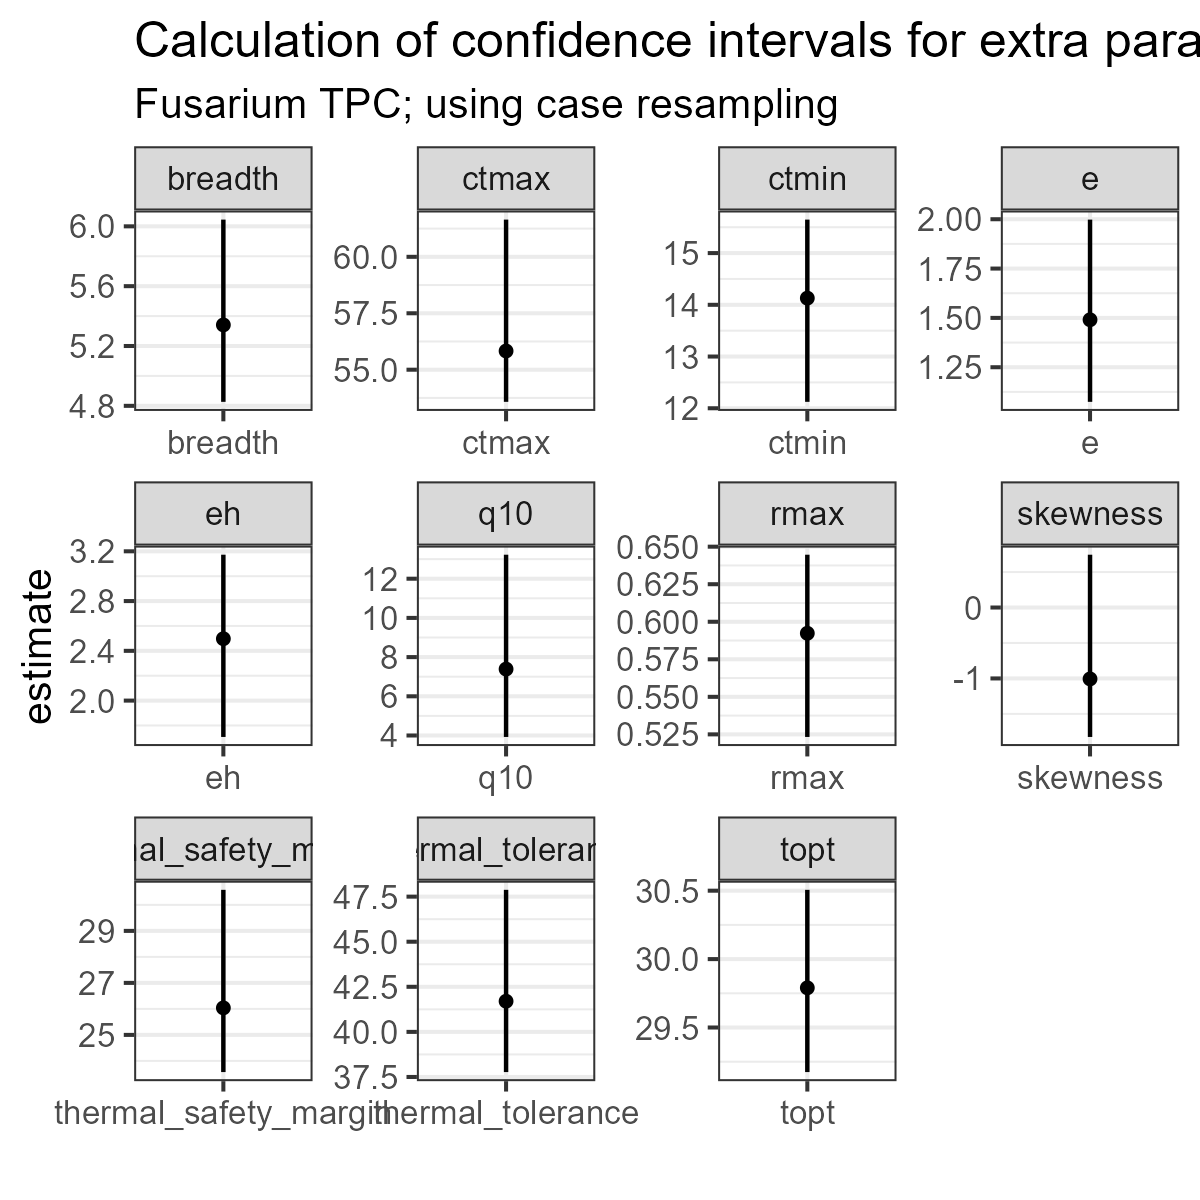